In [97]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import holidays as hld

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler #Para estandarizar
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [98]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [99]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [100]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [101]:
uber.describe()

,key,date,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,2012-03-22 15:02:18.433115648,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
min,1.000000e+00,2009-01-01 01:15:22.000000600,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,2010-08-25 08:20:16,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,2012-03-21 20:44:29.500000256,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,2013-10-19 02:14:16.500000512,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000
std,1.601382e+07,NaN,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997


### Creación de nuevas variables

In [102]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [103]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

uber["hora"] = uber["pickup_datetime"].dt.hour
uber["fecha"] = uber["pickup_datetime"].dt.date
uber["día"] = uber["pickup_datetime"].dt.day_name()
uber["num_dia"] = uber["pickup_datetime"].dt.weekday

us_holidays = hld.US()
us_holidays = hld.country_holidays('US')

nyse_holidays = hld.NYSE()
nyse_holidays = hld.financial_holidays('NYSE')

uber["feriado"] = uber["fecha"].apply(lambda x: x in us_holidays or x in nyse_holidays)

### Valores atipicos

In [104]:
precios_negativos_cero = uber[uber["fare_amount"] <= 0]
print(f"Viajes con costos negativos: {precios_negativos_cero['passenger_count'].count()}")
# hay 17 valores negativos y 5 con valor 0

Viajes con costos negativos: 22


In [105]:
uber[((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |
    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |
    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |
    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180))
    ]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,hora,fecha,día,num_dia,feriado
4949,42931506,2012-04-28 00:58:00.000000235,4.9,2012-04-28 00:58:00+00:00,-748.016667,40.739957,-74.003570,40.734192,1,2379.081331,0,2012-04-28,Saturday,5,False
32549,5634081,2012-06-16 10:04:00.000000610,15.7,2012-06-16 10:04:00+00:00,-74.016055,40.715155,-737.916665,40.697862,2,2885.814182,10,2012-06-16,Saturday,5,False
48506,1055960,2011-11-05 23:26:00.000000309,33.7,2011-11-05 23:26:00+00:00,-735.200000,40.770092,-73.980187,40.765530,1,3015.112108,23,2011-11-05,Saturday,5,False
56617,14257861,2012-03-11 07:24:00.000000310,8.1,2012-03-11 07:24:00+00:00,-73.960828,404.433332,-73.988357,40.769037,1,253.182192,7,2012-03-11,Sunday,6,False
61793,2849369,2012-06-13 05:45:00.000000600,8.5,2012-06-13 05:45:00+00:00,-73.951385,401.066667,-73.982110,40.754117,1,21.654631,5,2012-06-13,Wednesday,2,False
75851,33249845,2011-11-05 00:22:00.000000510,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1,10196.228613,0,2011-11-05,Saturday,5,False
91422,23566642,2011-05-18 13:24:00.000000213,16.1,2011-05-18 13:24:00+00:00,57.418457,1292.016128,1153.572603,-881.985513,1,1396.154787,13,2011-05-18,Wednesday,2,False
103745,16826862,2011-10-14 19:04:00.000000202,12.9,2011-10-14 19:04:00+00:00,-736.216667,40.767035,-73.982377,40.725562,1,2966.236350,19,2011-10-14,Friday,4,False
139447,39981694,2012-01-20 11:50:00.000000880,13.7,2012-01-20 11:50:00+00:00,-74.011042,40.709780,-73.983163,493.533332,4,6413.487601,11,2012-01-20,Friday,4,False
144253,9421322,2009-08-26 11:55:00.000000230,7.3,2009-08-26 11:55:00+00:00,-768.550000,40.757812,-73.997040,40.740007,1,1327.276030,11,2009-08-26,Wednesday,2,False


In [106]:
# Reemplazar valores 0 por NaN (porque son inválidos)
columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
uber[columnas_coords] = uber[columnas_coords].replace(0, np.nan)

# Reemplazar valores fuera de rango (latitudes: -90 a 90, longitudes: -180 a 180)
# Rango realista de coordenadas para NYC
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.3, -73.5
#lat_min, lat_max = 30, 45
#lon_min, lon_max = -80, -50

for col in columnas_coords:
    if 'latitude' in col:
        uber.loc[(uber[col] < lat_min) | (uber[col] > lat_max), col] = np.nan
    elif 'longitude' in col:
        uber.loc[(uber[col] < lon_min) | (uber[col] > lon_max), col] = np.nan

uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

# Reemplazar distancia inválida por NaN
uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x <= 0 else x)

# Eliminar outliers de distancia (basado en IQR)
q1 = uber["distancia"].quantile(0.25)
q3 = uber["distancia"].quantile(0.75)
iqr = q3 - q1
limite_inferior = max(q1 - 1.5 * iqr, 0)
limite_superior = q3 + 1.5 * iqr

uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x < limite_inferior or x > limite_superior else x)

# (OPCIONAL) Si querés, podés dejar esta línea comentada si vas a imputar distancia de otro modo
# uber.loc[uber['distancia'].isna(), columnas_coords] = np.nan

# Reemplazar valor imposible en cantidad de pasajeros
uber.loc[uber['passenger_count'] == 208, 'passenger_count'] = np.nan

# Eliminar tarifas <= 0
uber = uber[uber["fare_amount"] > 0]

# Eliminar outliers de tarifa
uber.drop(uber[uber["fare_amount"] > 300].index, inplace=True)

# MOSTRAR VALORES FALTANTES
print(uber.isna().sum())


key                      0
date                     0
fare_amount              0
pickup_datetime          0
pickup_longitude      4056
pickup_latitude       4044
dropoff_longitude     4025
dropoff_latitude      4038
passenger_count          1
distancia            22368
hora                     0
fecha                    0
día                      0
num_dia                  0
feriado                  0
dtype: int64


In [107]:
porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.01% de los datos


In [108]:
columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# Condición: al menos una coordenada es NaN o igual a 0
condicion_nan = uber[columnas_coords].isna().any(axis=1)
condicion_cero = (uber[columnas_coords] == 0).any(axis=1)

# Filas que cumplen alguna de las dos condiciones
filas_con_problemas = uber[condicion_nan | condicion_cero]

# Mostrar las filas con problemas en las coordenadas
print(filas_con_problemas[columnas_coords])

        pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude
7                   NaN               NaN               NaN                NaN
11                  NaN               NaN               NaN                NaN
65                  NaN               NaN               NaN                NaN
92                  NaN               NaN               NaN                NaN
120                 NaN               NaN               NaN                NaN
...                 ...               ...               ...                ...
199724              NaN               NaN               NaN                NaN
199880              NaN               NaN               NaN                NaN
199883              NaN               NaN               NaN                NaN
199936        40.774307               NaN         40.769672         -73.982215
199963              NaN               NaN               NaN                NaN

[4349 rows x 4 columns]


In [109]:
#if not (uber["pickup_latitude"].isna() | uber["pickup_longitude"].isna() | uber["dropoff_latitude"].isna() | uber["dropoff_longitude"].isna()):
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

In [110]:
uber[uber["distancia"].isna()]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,hora,fecha,día,num_dia,feriado
7,44195482,2012-12-11 13:52:00.000000290,2.5,2012-12-11 13:52:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,13,2012-12-11,Tuesday,1,False
11,6379048,2011-05-23 22:15:00.000000860,8.5,2011-05-23 22:15:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,22,2011-05-23,Monday,0,False
65,21993993,2014-05-05 19:27:00.000000340,6.0,2014-05-05 19:27:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,19,2014-05-05,Monday,0,False
92,1454546,2011-12-02 14:07:00.000000207,6.1,2011-12-02 14:07:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,14,2011-12-02,Friday,4,False
120,17358122,2010-08-20 19:39:48.000000300,6.5,2010-08-20 19:39:48+00:00,NaN,NaN,NaN,NaN,1.0,NaN,19,2010-08-20,Friday,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199724,46007628,2013-10-11 11:25:41.000000400,7.5,2013-10-11 11:25:41+00:00,NaN,NaN,NaN,NaN,1.0,NaN,11,2013-10-11,Friday,4,False
199880,35013970,2014-02-22 06:45:46.000000200,6.5,2014-02-22 06:45:46+00:00,NaN,NaN,NaN,NaN,1.0,NaN,6,2014-02-22,Saturday,5,False
199883,44115598,2012-09-10 17:39:00.000000900,12.5,2012-09-10 17:39:00+00:00,NaN,NaN,NaN,NaN,2.0,NaN,17,2012-09-10,Monday,0,False
199936,44787414,2012-07-21 16:19:00.000000990,4.1,2012-07-21 16:19:00+00:00,NaN,40.774307,-73.982215,40.769672,5.0,NaN,16,2012-07-21,Saturday,5,False


### Valores Nulos

In [111]:
#uber = uber.dropna(axis=0)
uber.isna().sum()


,0
key,0
date,0
fare_amount,0
pickup_datetime,0
pickup_longitude,4056
pickup_latitude,4044
dropoff_longitude,4025
dropoff_latitude,4038
passenger_count,1
distancia,4349


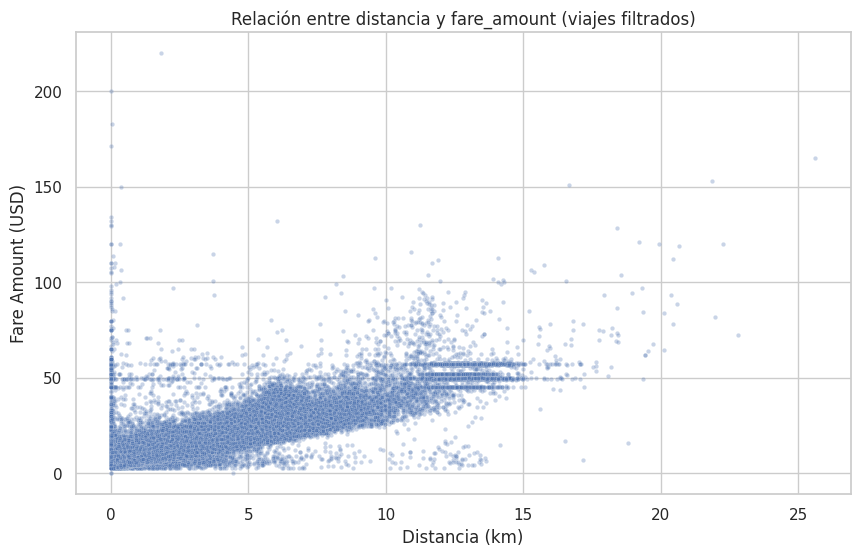

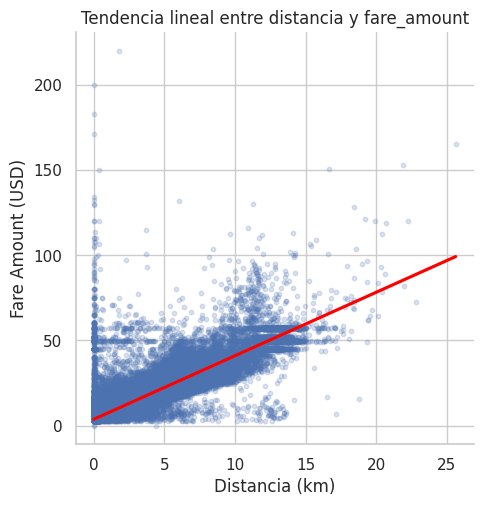

In [112]:
# GRAFICO FAIR AMOUNT DISTANCIA ANTES DE LA IMPUTACION

plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

In [113]:
# Reemplazo los valores por knn
#columnas_a_imputar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

#imputer = KNNImputer(n_neighbors=10)

#uber[columnas_a_imputar] = imputer.fit_transform(uber[columnas_a_imputar])

from sklearn.impute import KNNImputer
import numpy as np

# 1. Seleccionamos las columnas de coordenadas
columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# 2. Imputamos coordenadas con KNN
imputer = KNNImputer(n_neighbors=5)
coordenadas_imputadas = imputer.fit_transform(uber[columnas_coords])

# 3. Agregamos ruido gaussiano pequeño
#ruido = np.random.normal(loc=0, scale=0.0005, size=coordenadas_imputadas.shape)
#coordenadas_imputadas_con_ruido = coordenadas_imputadas + ruido

# 4. Asignamos de vuelta al dataframe
uber[columnas_coords] = coordenadas_imputadas


#
uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()

<ipython-input-113-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-113-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns, UTC], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-113-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger

In [114]:
#uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])
uber["distancia"] = distancia(
    uber["pickup_latitude"],
    uber["pickup_longitude"],
    uber["dropoff_latitude"],
    uber["dropoff_longitude"]
)

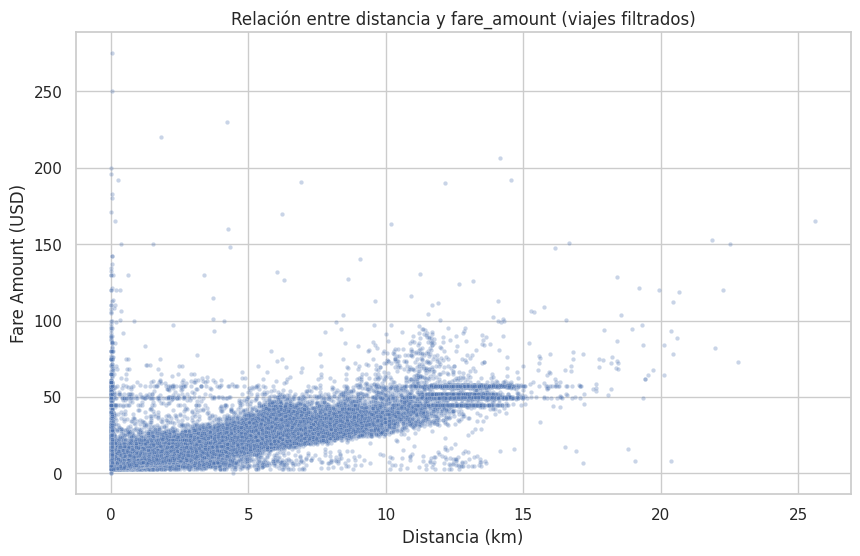

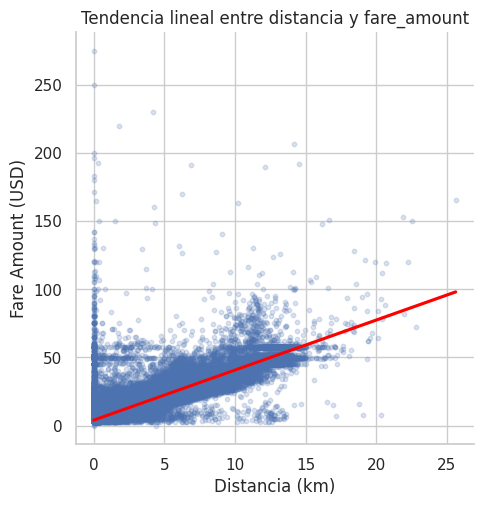

In [115]:
# GRAFICO FAIR AMOUNT DISTANCIA DESPUES DE LA IMPUTACION

plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

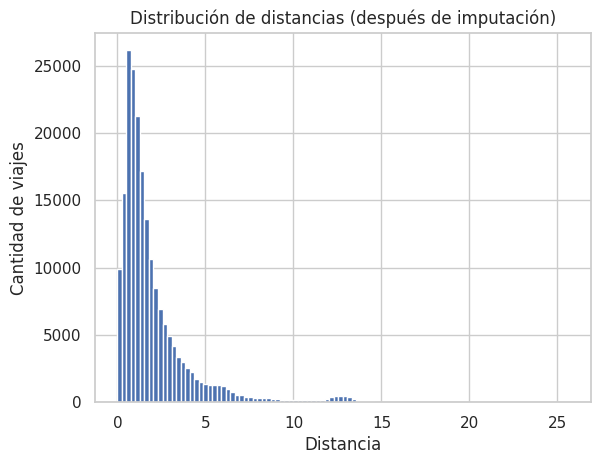

In [116]:
plt.hist(uber['distancia'], bins=100)
plt.title("Distribución de distancias (después de imputación)")
plt.xlabel("Distancia")
plt.ylabel("Cantidad de viajes")
plt.show()

### Graficos

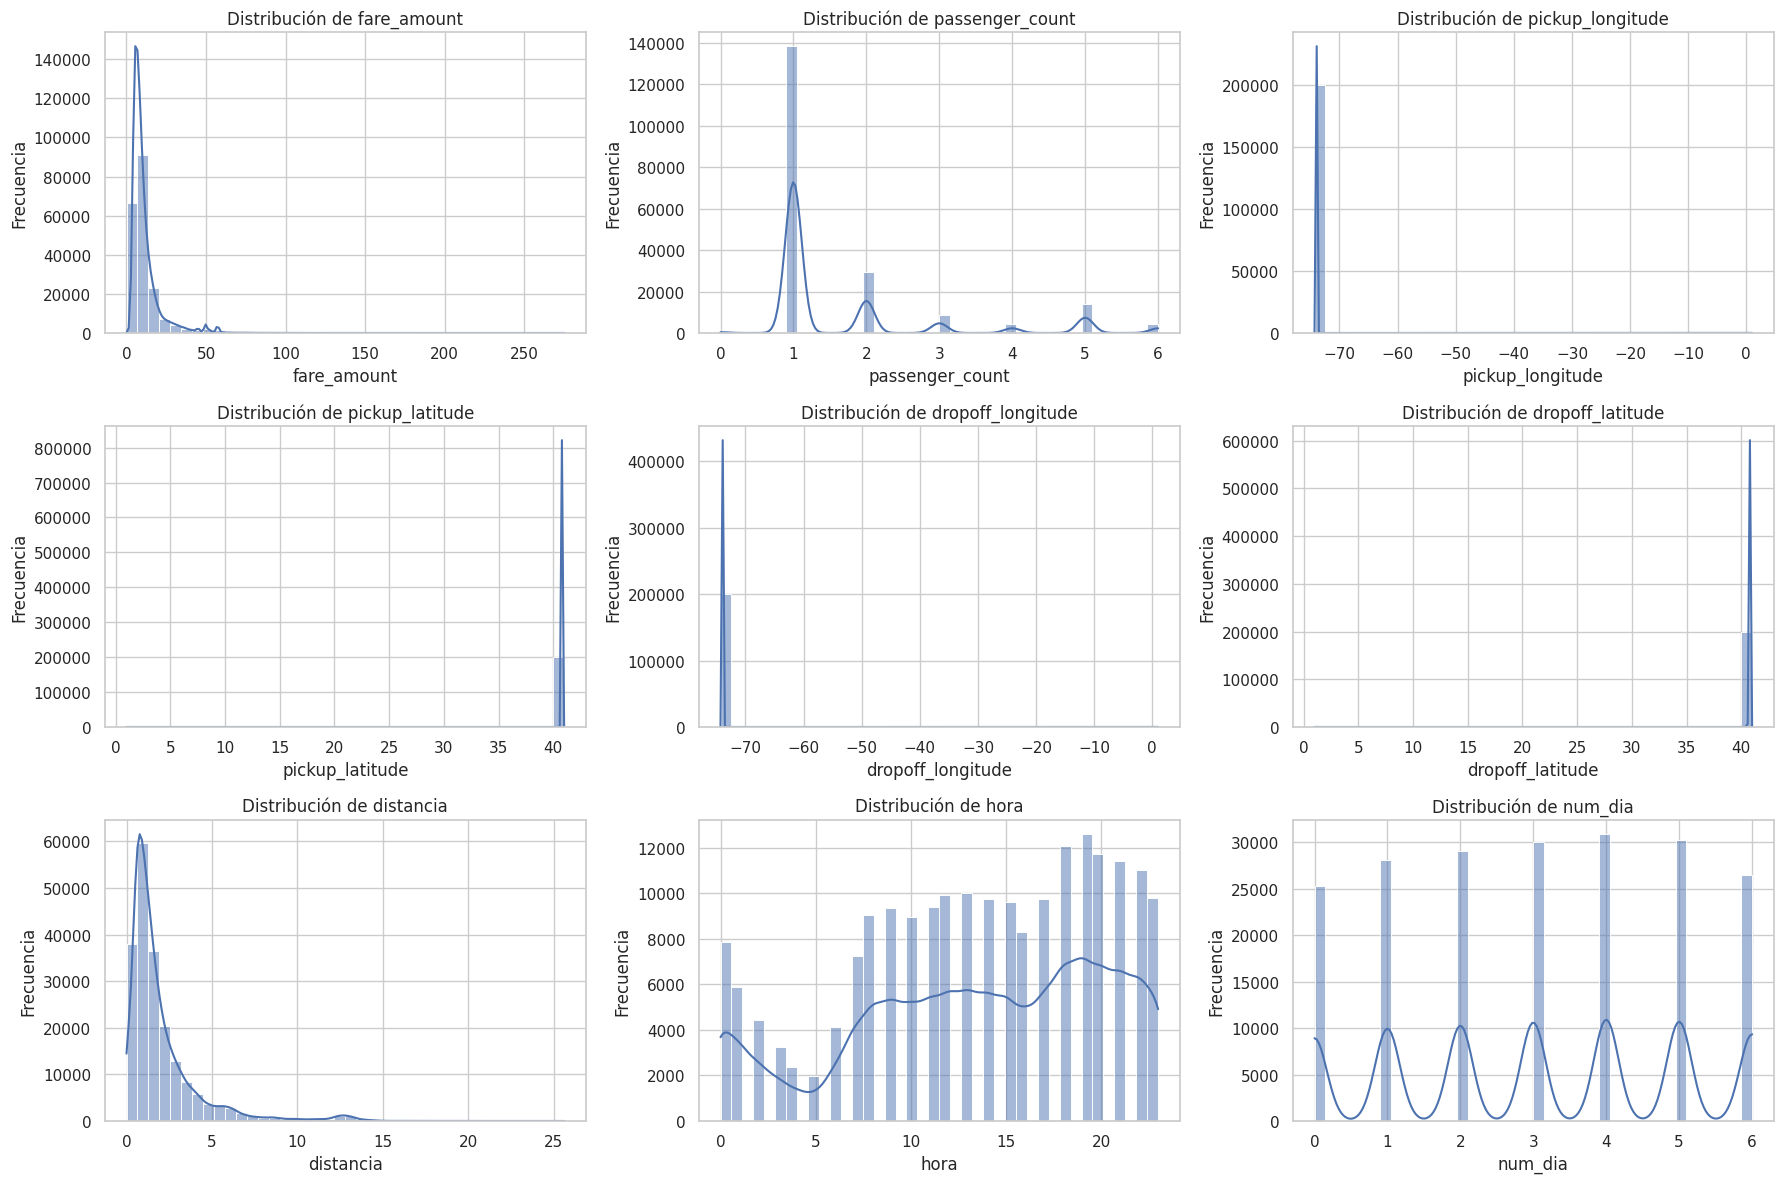

In [117]:
# Variables numéricas relevantes
variables = ["fare_amount", "passenger_count", "pickup_longitude", "pickup_latitude",
             "dropoff_longitude", "dropoff_latitude", "distancia", "hora", "num_dia"]

# Estilo
sns.set(style="whitegrid")

# Creamos los subplots
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

# Generamos un histograma por cada variable
for i, col in enumerate(variables):
    sns.histplot(data=uber, x=col, bins=40, ax=axs[i], kde=True)
    axs[i].set_title(f"Distribución de {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

heatmap hora vs día para ver en qué momento del día hay más viajes según el día de la semana

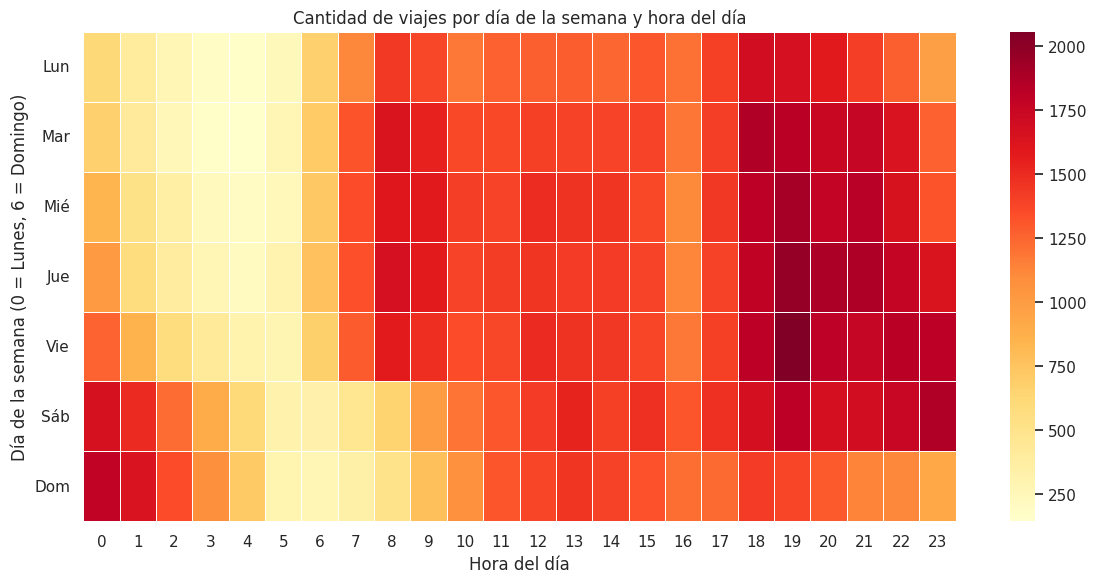

In [118]:
# Creamos una tabla resumen con la cantidad de viajes por día y hora
heatmap_data = uber.groupby(["num_dia", "hora"]).size().unstack(fill_value=0)

# Creamos el heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=0.5)

# Títulos y etiquetas
plt.title("Cantidad de viajes por día de la semana y hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0 = Lunes, 6 = Domingo)")
plt.yticks(ticks=[i + 0.5 for i in range(7)], labels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], rotation=0)

plt.tight_layout()
plt.show()

fare_amount

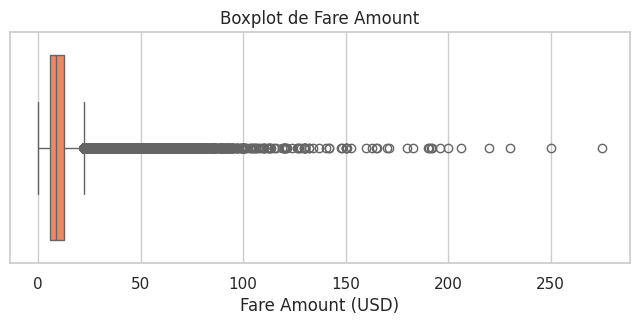

In [119]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=uber["fare_amount"], color="coral")
plt.title("Boxplot de Fare Amount")
plt.xlabel("Fare Amount (USD)")
plt.show()


passenger_count vs fare_amount (¿hay correlación entre los pasajeros y el precio?)

<ipython-input-120-b73ae6cab775>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uber, x="passenger_count", y="fare_amount", palette="Set2")


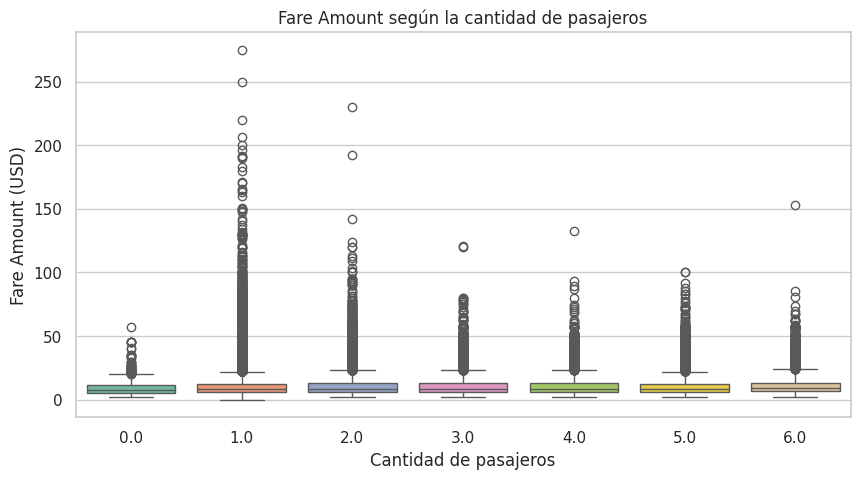

In [120]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=uber, x="passenger_count", y="fare_amount", palette="Set2")
plt.title("Fare Amount según la cantidad de pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Fare Amount (USD)")
plt.show()

fare_amount vs distancia

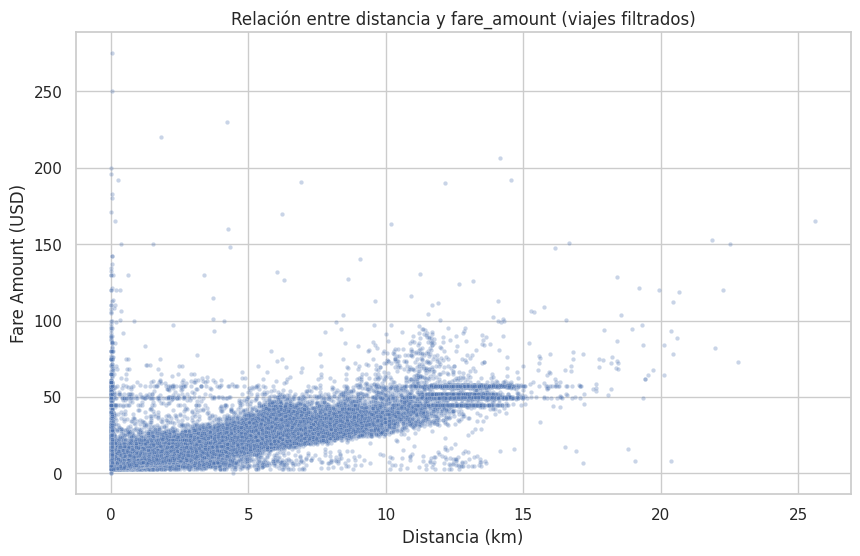

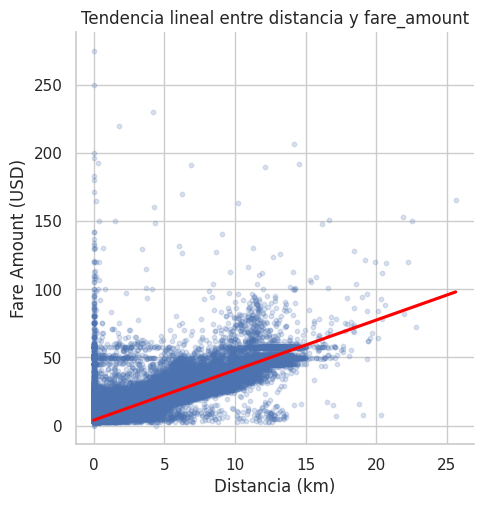

In [121]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()


In [122]:
columnas_sin_corr = ["fare_amount", "passenger_count", "distancia", "día", "feriado","key","fecha","pickup_datetime"]
matriz = uber.drop(columns=columnas_sin_corr)
corr = matriz.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title("Matriz de correlación")
plt.show()

TypeError: float() argument must be a string or a real number, not 'Timestamp'

### Estandarización y division del dataset

In [123]:
'''
columnas_cualitativas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")
X_estandarizado = scaler.fit_transform(uber[columnas_cualitativas])
X_estandarizado["feriado"] = uber["feriado"]
X_estandarizado["dia"] = uber["num_dia"]
X_estandarizado["hora"] = uber["hora"]
y = uber["fare_amount"]
'''

columnas_cualitativas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")

# Escalar y resetear índice
X_scaled = scaler.fit_transform(uber[columnas_cualitativas]).reset_index(drop=True)

# Concatenar con otras columnas (también con índice reseteado)
otras_columnas = uber[["feriado", "num_dia", "hora"]].reset_index(drop=True)

# Combinar todo
X_estandarizado = pd.concat([X_scaled, otras_columnas], axis=1)

# Target
y = uber["fare_amount"].reset_index(drop=True)

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X_estandarizado, y, test_size=0.2, random_state=42)

## Modelos de regresión

### Regresión lineal
$$
\text{fare\_amount} = 11.69 + 0.099 \cdot \text{passenger\_count} + 0.542 \cdot \text{distancia} - 0.0077 \cdot \text{feriado} + 0.0247 \cdot \text{dia} - 0.0311 \cdot \text{hora}
$$

In [125]:
X_train.columns

Index(['passenger_count', 'distancia', 'feriado', 'num_dia', 'hora'], dtype='object')

In [126]:
modelo = LinearRegression().fit(X_train,y_train)

In [127]:
modelo.coef_

array([ 3.79622802e-02,  8.18252120e+00, -5.29840638e-01, -3.76663966e-02,
        6.38110243e-03])

In [128]:
modelo.intercept_

np.float64(11.401317848971761)

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Métricas
def print_metrics(y_true, y_pred, dataset=""):
    print(f"--- {dataset} ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))

print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Prueba")

--- Entrenamiento ---
R2 Score: 0.6911499154921845
MSE: 30.073925160429766
RMSE: 5.483969835842441
MAE: 2.6055855891128354
--- Prueba ---
R2 Score: 0.6973042165213563
MSE: 27.681827640422075
RMSE: 5.2613522634796155
MAE: 2.5793880307925425


### Gradiente descendiente

In [130]:
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='invscaling', eta0=0.01, max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd_train = sgd.predict(X_train)
y_pred_sgd_test = sgd.predict(X_test)

print_metrics(y_train, y_pred_sgd_train, "Entrenamiento (SGD)")
print_metrics(y_test, y_pred_sgd_test, "Prueba (SGD)")


--- Entrenamiento (SGD) ---
R2 Score: 0.6750810038066105
MSE: 31.63861713133088
RMSE: 5.6248215199534
MAE: 2.577701288440807
--- Prueba (SGD) ---
R2 Score: 0.680026368608933
MSE: 29.2619038555996
RMSE: 5.4094273130895845
MAE: 2.562156389186619
